# LeNet-5 Implementation in PyTorch

This notebook contains the implementation of the LeNet-5 architecture using PyTorch.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        # Layer 1: Convolutional layer with 6 filters of size 5x5, padding 2
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2)
        # Layer 2: Max Pooling layer with 2x2 kernel and stride 2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Layer 3: Convolutional layer with 16 filters of size 5x5
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1)
        # Layer 4: Max Pooling layer with 2x2 kernel and stride 2
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Layer 5: Convolutional layer with 120 filters of size 5x5
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1)

        # Layer 6: Fully connected layer
        self.fc1 = nn.Linear(in_features=120, out_features=84)

        # Layer 7: Output layer
        self.fc2 = nn.Linear(in_features=84, out_features=num_classes)

    def forward(self, x):
        # Pass through first conv + pool
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        # Pass through second conv + pool
        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        # Pass through third conv
        x = F.relu(self.conv3(x))

        # Flatten and pass through fully connected layers
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))

        # Output layer (no activation here, usually handled by CrossEntropyLoss)
        x = self.fc2(x)
        return x

In [2]:
# Instantiate the model
model = LeNet5(num_classes=10)
print(model)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=120, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=10, bias=True)
)


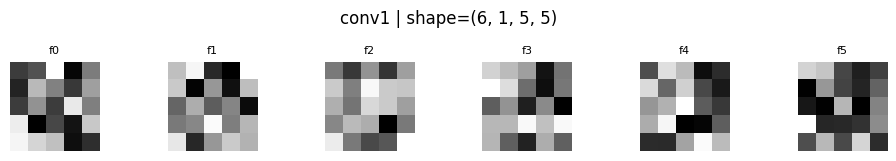

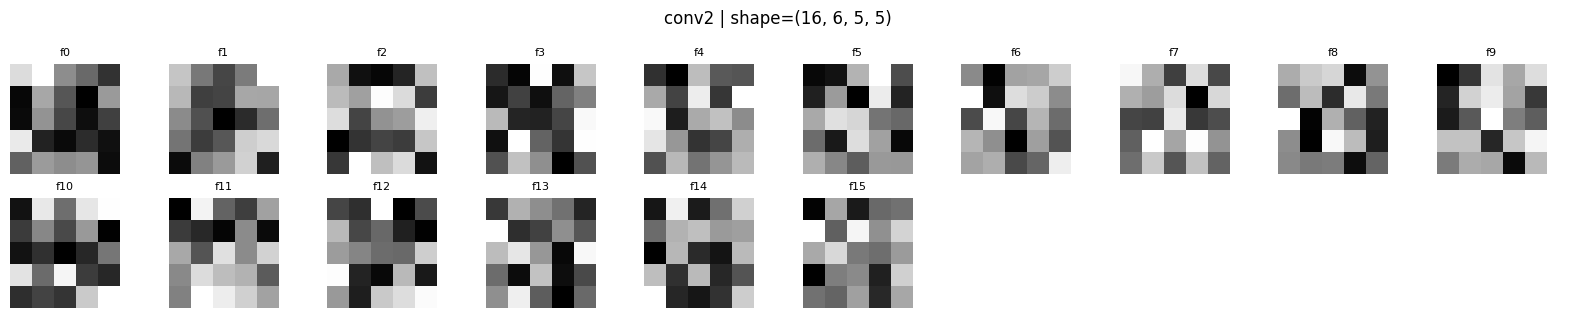

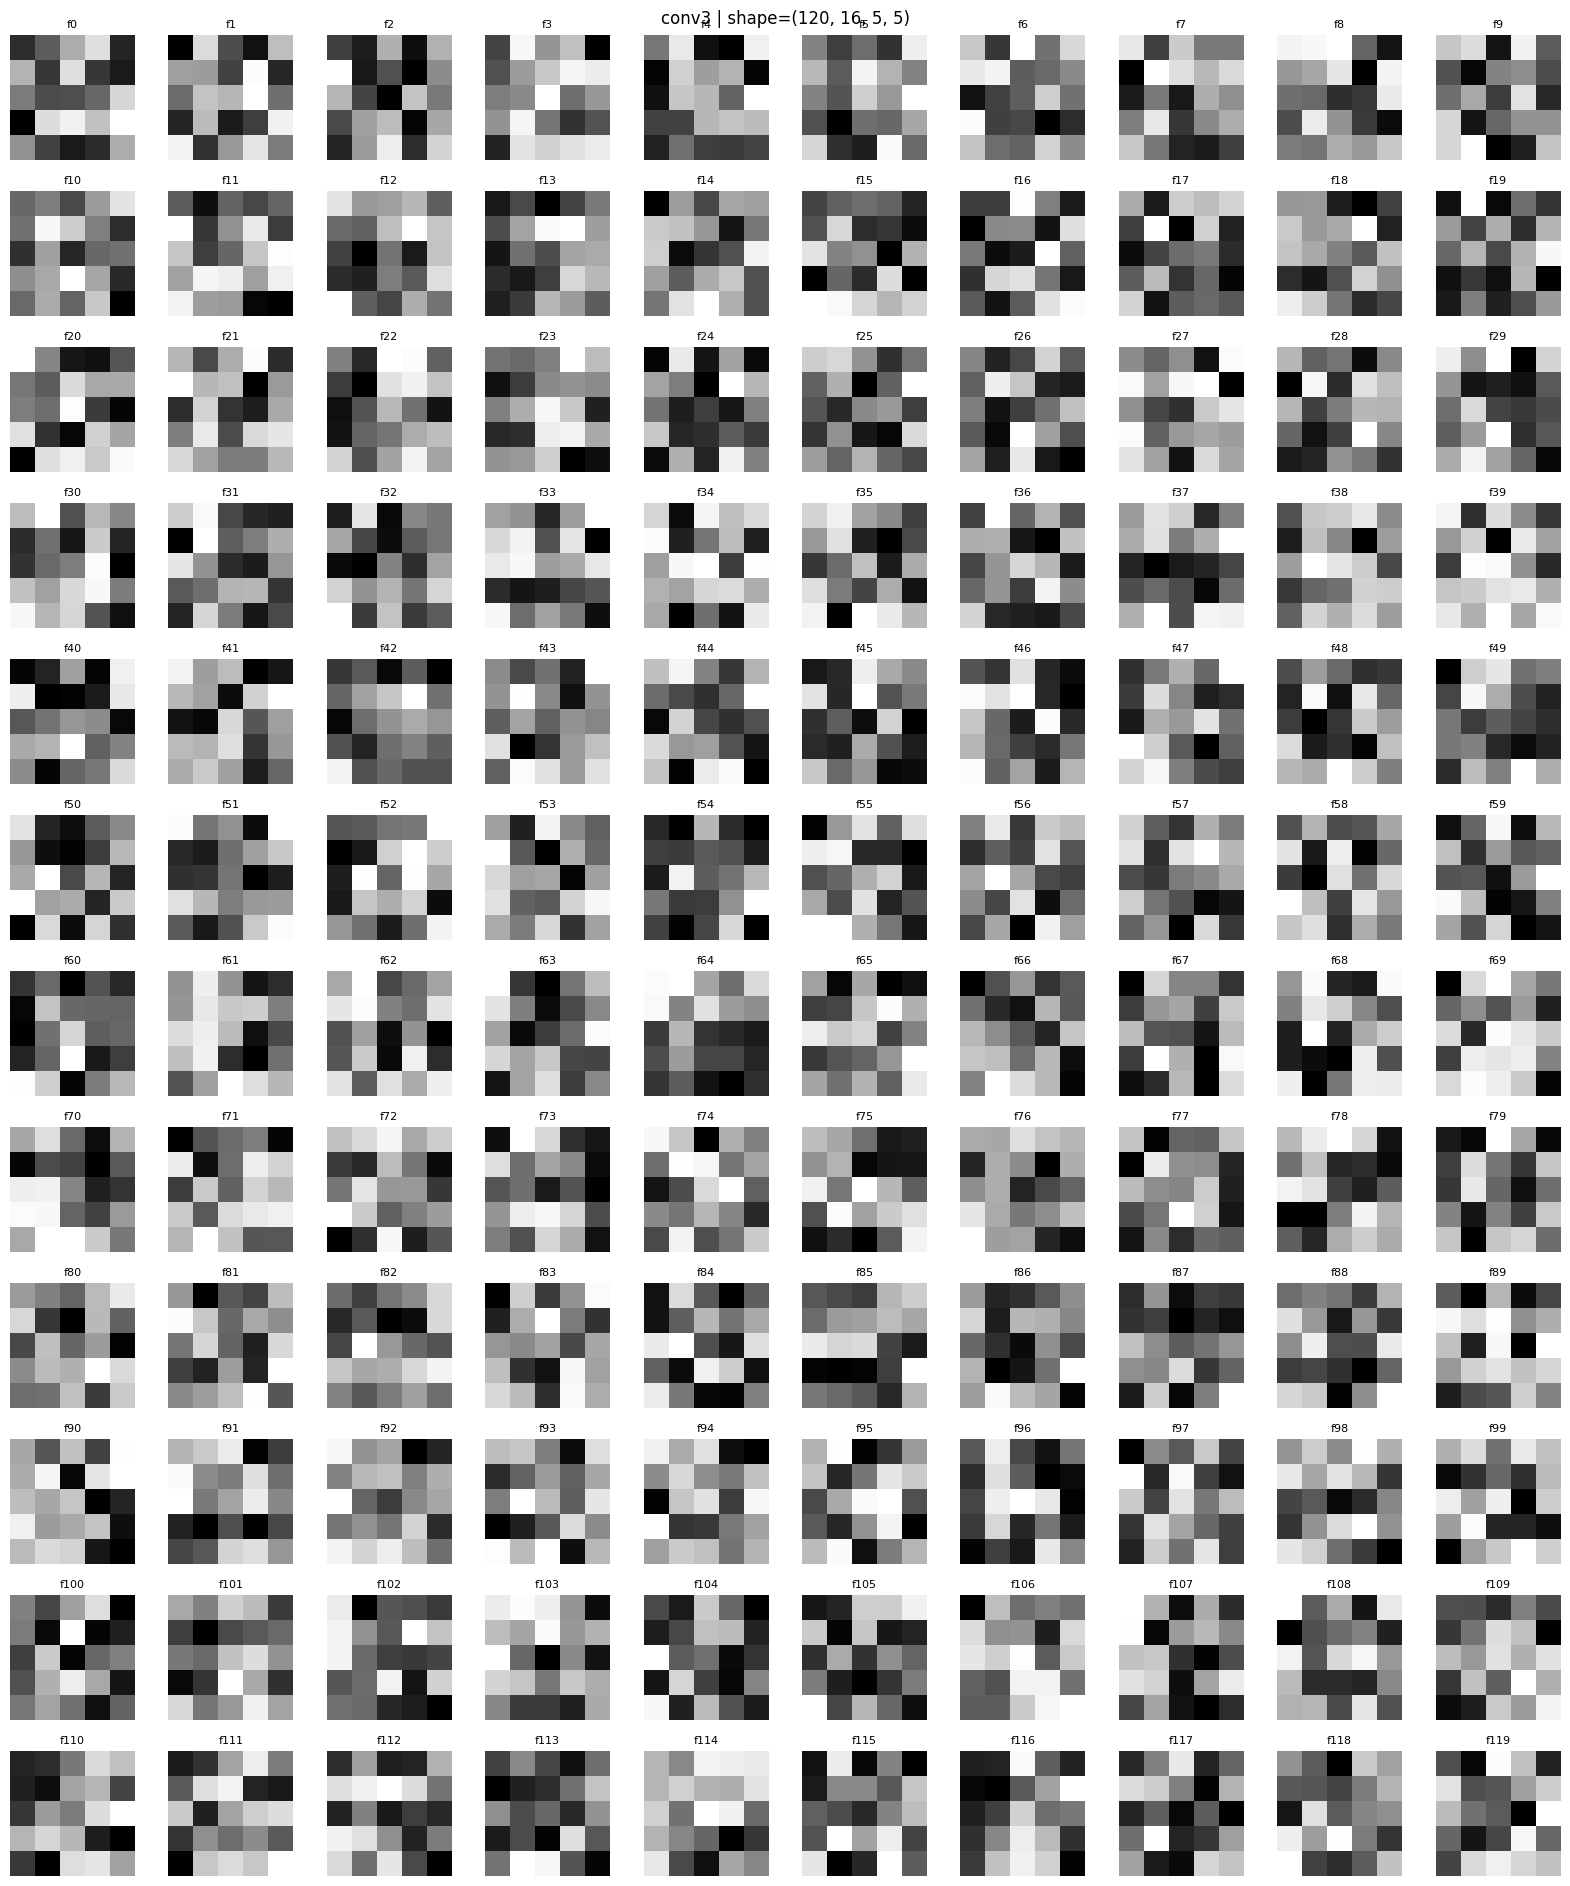

In [3]:
# Visualização dos filtros convolucionais iniciais (antes do treinamento)
import math
import matplotlib.pyplot as plt

with torch.no_grad():
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            weights = module.weight.detach().cpu()

            # Mostra todos os filtros de saída usando o primeiro canal de entrada
            filters = weights[:, 0, :, :]
            n_filters = filters.shape[0]
            cols = min(10, n_filters)
            rows = math.ceil(n_filters / cols)

            fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.6))
            axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

            for i in range(len(axes)):
                ax = axes[i]
                ax.axis("off")
                if i < n_filters:
                    ax.imshow(filters[i], cmap="gray")
                    ax.set_title(f"f{i}", fontsize=8)

            fig.suptitle(f"{name} | shape={tuple(weights.shape)}", fontsize=12)
            plt.tight_layout()
            plt.show()

100.0%
100.0%
100.0%
100.0%


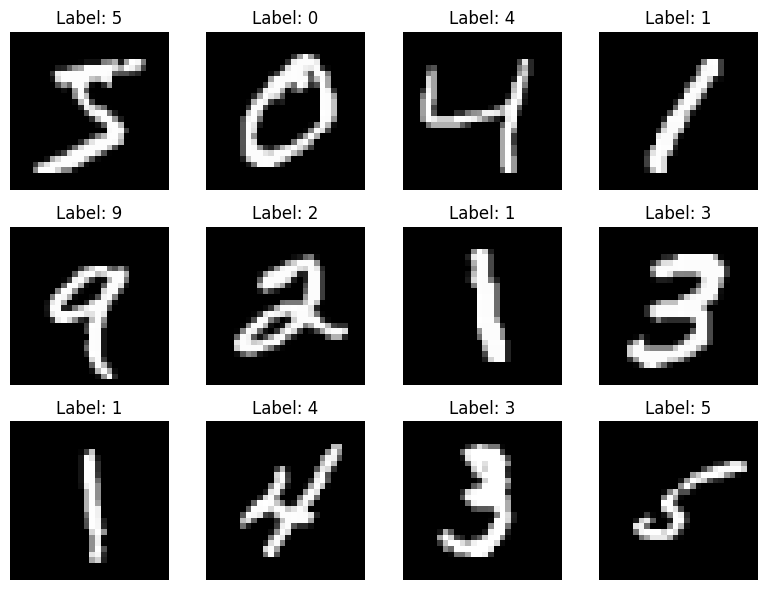

In [4]:
import ssl
from torchvision import datasets, transforms

# Fallback para ambientes com erro de cadeia de certificados SSL
# (remove a verificação apenas para permitir o download do dataset)
ssl._create_default_https_context = ssl._create_unverified_context

transform = transforms.ToTensor()
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# Exibe alguns exemplos do dataset
num_examples = 12
fig, axes = plt.subplots(3, 4, figsize=(8, 6))
axes = axes.flatten()

for i in range(num_examples):
    image, label = mnist_train[i]
    axes[i].imshow(image.squeeze(0), cmap="gray")
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [5]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.optim as optim

# Hyperparameters
learning_rate = 0.001
batch_size = 64
num_epochs = 5

# Usa os arquivos do MNIST já baixados localmente
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root="./data", train=True, download=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Epoch [{epoch + 1}/{num_epochs}] - loss: {epoch_loss:.4f} - acc: {epoch_acc:.4f}")

Epoch [1/5] - loss: 0.2916 - acc: 0.9126
Epoch [2/5] - loss: 0.0804 - acc: 0.9749
Epoch [3/5] - loss: 0.0562 - acc: 0.9822
Epoch [4/5] - loss: 0.0450 - acc: 0.9859
Epoch [5/5] - loss: 0.0357 - acc: 0.9885


In [ ]:
# Avaliação no conjunto de teste
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.ToTensor()
test_dataset = datasets.MNIST(root="./data", train=False, download=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

avg_test_loss = test_loss / total
test_accuracy = correct / total

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")